# MechanoPro-DB External Evaluation: Ground-Truth vs ColabFold-Predicted Structures

This notebook evaluates the structure-based hbond/topology mechanical-property predictor on an external experimental dataset, **MechanoPro-DB**.

The dataset contains experimental unfolding/clamp forces, not the same simulation targets used to train the predictor. Therefore the evaluation focuses on rank/linear association between experimental force and the two predicted quantities:

- predicted toughness-like score (`v127` head);
- predicted strength-like score (`v128` head).

Duplicate PDB IDs are aggregated by the mean experimental force, while retaining measurement count and dispersion.


In [1]:
from __future__ import annotations

import json
import math
import os
import re
import select
import subprocess
import sys
import time
from pathlib import Path
from typing import Optional
from urllib.request import urlopen, Request
from urllib.error import HTTPError, URLError

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'model').is_dir() and (candidate / 'README.md').exists():
            return candidate
    return start

REPO_ROOT = find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DATA_PATH = REPO_ROOT / 'model/reward_module/mechanical-properties-predictor/MechanoPro-DB.csv'
OUT_DIR = REPO_ROOT / 'output/evaluate-mechanical-predictor/compared_based_predicted-MechanoPro-DB'
FIGURE_DIR = OUT_DIR / 'figures'
TABLE_DIR = OUT_DIR / 'tables'
RCSB_PDB_DIR = OUT_DIR / 'groundtruth-rcsb-pdb'
PREDICT_ROOT = REPO_ROOT / 'output/evaluate-mechanical-predictor/pdb-colab/compared_based_predicted-MechanoPro-DB'
COLABFOLD_INPUT_DIR = PREDICT_ROOT / 'input-fasta'
COLABFOLD_RESULT_DIR = PREDICT_ROOT / 'results'
COLABFOLD_DATA_DIR = REPO_ROOT / 'output/evaluate-mechanical-predictor/colabfold-local-data'
LOCAL_AFDB_PARAMS_DIR = Path('/mnt/nas/jianquanzhao/afdb/params')

COLABFOLD_BIN = Path('/mnt/data1/home/jianquanzhao/anaconda24/envs/colabfold/bin/colabfold_batch')
EVAL_ENV_PYTHON = Path('/home/jianquanzhao/anaconda24/envs/mprl-vgpt/bin/python')
CUDA_HOME = Path('/mnt/data2/jianquanzhao/cuda/cuda-12.8')
MODEL_ARTIFACT_PATH = REPO_ROOT / 'params/hbond_random_forest.joblib'

for path in [OUT_DIR, FIGURE_DIR, TABLE_DIR, RCSB_PDB_DIR, PREDICT_ROOT, COLABFOLD_INPUT_DIR, COLABFOLD_RESULT_DIR, COLABFOLD_DATA_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# Full external evaluation setting. Set to an integer for quick debugging.
MAX_ENTRIES: Optional[int] = None
RUN_RCSB_DOWNLOAD = True
RUN_COLABFOLD = True
REQUIRE_GPU_FOR_COLABFOLD = True
OVERWRITE_EXISTING_RESULTS = False
STARTUP_LOG_TIMEOUT_SECONDS = 180

print('Repo root:', REPO_ROOT)
print('MechanoPro CSV exists:', DATA_PATH.exists(), DATA_PATH)
print('ColabFold binary exists:', COLABFOLD_BIN.exists(), COLABFOLD_BIN)
print('Evaluation env python exists:', EVAL_ENV_PYTHON.exists(), EVAL_ENV_PYTHON)
print('CUDA path exists:', CUDA_HOME.exists(), CUDA_HOME)
print('Model artifact exists:', MODEL_ARTIFACT_PATH.exists(), MODEL_ARTIFACT_PATH)


Repo root: /mnt/nas/jianquanzhao/gits/Mechanical-protein-RL
MechanoPro CSV exists: True /mnt/nas/jianquanzhao/gits/Mechanical-protein-RL/model/reward_module/mechanical-properties-predictor/MechanoPro-DB.csv
ColabFold binary exists: True /mnt/data1/home/jianquanzhao/anaconda24/envs/colabfold/bin/colabfold_batch
Evaluation env python exists: True /home/jianquanzhao/anaconda24/envs/mprl-vgpt/bin/python
CUDA path exists: True /mnt/data2/jianquanzhao/cuda/cuda-12.8
Model artifact exists: True /mnt/nas/jianquanzhao/gits/Mechanical-protein-RL/params/hbond_random_forest.joblib


## 1. Parse MechanoPro-DB and Aggregate Duplicate PDB IDs

The force column has leading whitespace in the raw CSV header, so all column names are normalized with `strip()` first. Duplicate PDB IDs are aggregated by mean force because repeated entries usually correspond to different measurement modes or constructs.


In [2]:
def parse_force(value: object) -> float:
    if pd.isna(value):
        return np.nan
    text = str(value).strip().replace(',', '')
    # Keep the first numeric token. This handles simple entries such as "200" and tolerates light annotations.
    match = re.search(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', text)
    return float(match.group(0)) if match else np.nan


def normalize_pdb_id(value: object) -> Optional[str]:
    if pd.isna(value):
        return None
    text = str(value).strip().upper()
    match = re.search(r'[0-9][A-Z0-9]{3}', text)
    return match.group(0) if match else None

raw = pd.read_csv(DATA_PATH)
raw.columns = [column.strip() for column in raw.columns]
force_col = 'Highest unfolding forces/ Clamp forces [pN]'
raw['pdb_id'] = raw['PDB ID'].map(normalize_pdb_id)
raw['experimental_force_pn'] = raw[force_col].map(parse_force)
raw['entry_description'] = raw['Name (Click for details)'].astype(str)

clean = raw.dropna(subset=['pdb_id', 'experimental_force_pn']).copy()
clean = clean[clean['experimental_force_pn'] >= 0].copy()

agg = clean.groupby('pdb_id', as_index=False).agg(
    experimental_force_pn=('experimental_force_pn', 'mean'),
    force_std_pn=('experimental_force_pn', 'std'),
    force_min_pn=('experimental_force_pn', 'min'),
    force_max_pn=('experimental_force_pn', 'max'),
    n_measurements=('experimental_force_pn', 'size'),
    entry_descriptions=('entry_description', lambda x: ' || '.join(sorted(set(map(str, x)))[:8])),
    techniques=('Technique', lambda x: ' || '.join(sorted(set(map(str, x.dropna())))[:8]) if hasattr(x, 'dropna') else ''),
    pulling_modes=('Pulling Mode', lambda x: ' || '.join(sorted(set(map(str, x.dropna())))[:8]) if hasattr(x, 'dropna') else ''),
    total_length_aa=('Total Length (AA)', 'mean'),
)
agg['force_std_pn'] = agg['force_std_pn'].fillna(0.0)
agg = agg.sort_values(['pdb_id']).reset_index(drop=True)
if MAX_ENTRIES is not None:
    agg = agg.head(MAX_ENTRIES).copy()

raw.to_csv(TABLE_DIR / 'mechanopro_raw_normalized.csv', index=False)
clean.to_csv(TABLE_DIR / 'mechanopro_clean_measurements.csv', index=False)
agg.to_csv(TABLE_DIR / 'mechanopro_pdb_aggregated_entries.csv', index=False)

summary = {
    'raw_rows': int(len(raw)),
    'clean_measurement_rows': int(len(clean)),
    'unique_pdb_entries': int(len(agg)),
    'duplicate_pdb_entries': int((clean['pdb_id'].value_counts() > 1).sum()),
    'force_min_pn': float(agg['experimental_force_pn'].min()),
    'force_median_pn': float(agg['experimental_force_pn'].median()),
    'force_mean_pn': float(agg['experimental_force_pn'].mean()),
    'force_max_pn': float(agg['experimental_force_pn'].max()),
}
print(json.dumps(summary, indent=2))
display(agg.head(20))


{
  "raw_rows": 85,
  "clean_measurement_rows": 85,
  "unique_pdb_entries": 38,
  "duplicate_pdb_entries": 22,
  "force_min_pn": 0.0,
  "force_median_pn": 157.66666666666669,
  "force_mean_pn": 261.18055555555554,
  "force_max_pn": 1325.0
}


,pdb_id,experimental_force_pn,force_std_pn,force_min_pn,force_max_pn,n_measurements,entry_descriptions,techniques,pulling_modes,total_length_aa
0,1AJ3,50.000000,28.284271,30.0,70.0,2,R16 repeat of Spectrin || Spectrin,AFM,constant velocity,106.00
1,1ANU,514.666667,325.308059,214.0,860.0,3,scaffoldin c2A | Cohesin 2 DOMAIN OF THE CELLU...,AFM || all atom SMD simulation,constant velocity,138.00
2,1AOH,850.000000,456.398948,480.0,1360.0,3,scaffoldin c7A | 1AOH: SINGLE COHESIN DOMAIN ...,AFM || all atom SMD simulation,constant velocity,147.00
3,1AT9,133.333333,28.867513,100.0,150.0,3,G241C mutant of bacteriodepsin | 1AT9: STRUCTU...,AFM,constant velocity,231.00
4,1B6I,64.000000,0.000000,64.0,64.0,1,T4 Lysozyme | 1B6I: T4 LYSOZYME MUTANT WITH C...,Scanning Force Microscope (SFM),constant velocity,162.00
5,1B9C,104.000000,0.000000,104.0,104.0,2,GFP linked to DdFLN1-5 [actin crosslinker dict...,AFM,constant velocity,227.00
6,1BNI,269.000000,0.000000,269.0,269.0,1,Barnase,all atom SMD simulation,constant velocity,110.00
7,1BNR,70.000000,0.000000,70.0,70.0,1,Barnase linked to I27 | 1BNR: BARNASE,AFM,constant velocity,110.00
8,1BRF,200.000000,0.000000,200.0,200.0,1,Rubredoxin,AFM,constant velocity,53.00
9,1CFC,0.000000,0.000000,0.0,0.0,1,calmodulin | FREE CALMODULIN,AFM,constant velocity,148.00


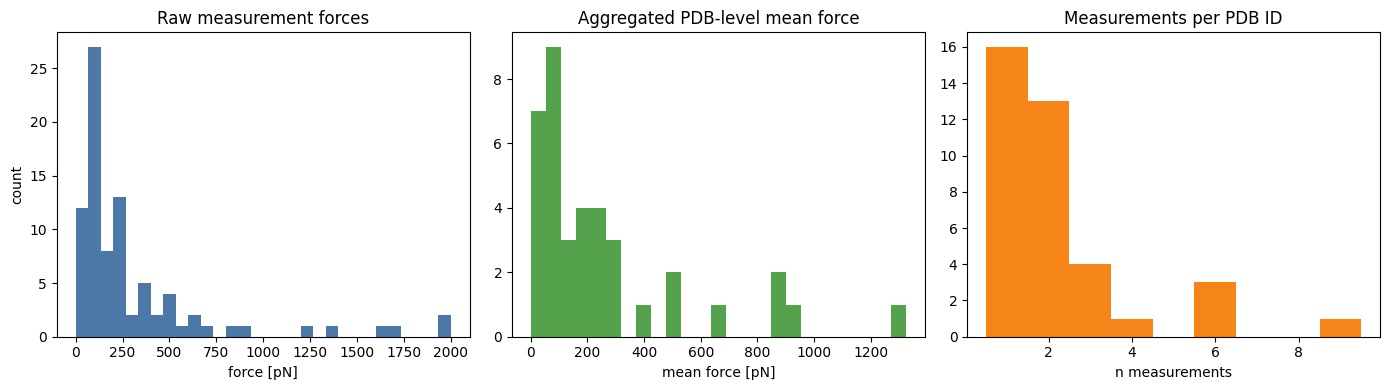

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(clean['experimental_force_pn'], bins=30, color='#4C78A8')
axes[0].set_title('Raw measurement forces')
axes[0].set_xlabel('force [pN]')
axes[0].set_ylabel('count')
axes[1].hist(agg['experimental_force_pn'], bins=25, color='#54A24B')
axes[1].set_title('Aggregated PDB-level mean force')
axes[1].set_xlabel('mean force [pN]')
axes[2].hist(agg['n_measurements'], bins=range(1, int(agg['n_measurements'].max()) + 2), color='#F58518', align='left')
axes[2].set_title('Measurements per PDB ID')
axes[2].set_xlabel('n measurements')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'mechanopro_force_and_duplicates.png', dpi=200)
plt.show()


## 2. Download Ground-Truth Structures from RCSB and Parse Sequences


In [4]:
def download_rcsb_pdb(pdb_id: str, out_dir: Path = RCSB_PDB_DIR, overwrite: bool = False) -> Optional[Path]:
    out_path = out_dir / f'{pdb_id}.pdb'
    if out_path.exists() and out_path.stat().st_size > 0 and not overwrite:
        return out_path
    url = f'https://files.rcsb.org/download/{pdb_id}.pdb'
    try:
        request = Request(url, headers={'User-Agent': 'Mechanical-protein-RL/MechanoPro-evaluation'})
        with urlopen(request, timeout=60) as response:
            data = response.read()
        if not data.startswith((b'HEADER', b'TITLE', b'COMPND', b'ATOM')):
            # Some PDB files start with REMARK or other records; still keep non-empty responses.
            if len(data) < 100:
                return None
        out_path.write_bytes(data)
        return out_path
    except (HTTPError, URLError, TimeoutError, OSError) as exc:
        print(f'Failed to download {pdb_id}: {exc}')
        return None


def sequence_from_pdb(path: Path) -> str:
    three_to_one = {
        'ALA':'A','ARG':'R','ASN':'N','ASP':'D','CYS':'C','GLN':'Q','GLU':'E','GLY':'G','HIS':'H','ILE':'I',
        'LEU':'L','LYS':'K','MET':'M','PHE':'F','PRO':'P','SER':'S','THR':'T','TRP':'W','TYR':'Y','VAL':'V',
        'SEC':'U','PYL':'O',
    }
    residues = []
    seen = set()
    for line in path.read_text(encoding='utf-8', errors='ignore').splitlines():
        if not line.startswith('ATOM'):
            continue
        altloc = line[16:17].strip()
        if altloc not in {'', 'A'}:
            continue
        resn = line[17:20].strip().upper()
        chain = line[21:22].strip() or '_'
        try:
            resi = int(line[22:26])
        except ValueError:
            continue
        icode = line[26:27].strip()
        key = (chain, resi, icode)
        if key in seen or resn not in three_to_one:
            continue
        seen.add(key)
        residues.append((chain, resi, icode, three_to_one[resn]))
    if not residues:
        return ''
    # Use all canonical residues across chains because MechanoPro entries can be complexes.
    return ''.join(item[3] for item in residues)

records = []
for row in agg.itertuples(index=False):
    pdb_path = download_rcsb_pdb(row.pdb_id) if RUN_RCSB_DOWNLOAD else (RCSB_PDB_DIR / f'{row.pdb_id}.pdb')
    sequence = sequence_from_pdb(pdb_path) if pdb_path and pdb_path.exists() else ''
    records.append({
        **row._asdict(),
        'groundtruth_pdb_path': str(pdb_path) if pdb_path else '',
        'groundtruth_pdb_exists': bool(pdb_path and pdb_path.exists()),
        'sequence': sequence,
        'sequence_length_from_pdb': len(sequence),
    })
entries = pd.DataFrame(records)
entries = entries[entries['sequence'].astype(str).str.len() > 0].copy()
entries['job_id'] = entries['pdb_id']
entries.to_csv(TABLE_DIR / 'mechanopro_entries_with_sequences.csv', index=False)

print('entries with sequence:', len(entries), 'of', len(agg))
display(entries[['pdb_id', 'experimental_force_pn', 'n_measurements', 'groundtruth_pdb_exists', 'sequence_length_from_pdb', 'groundtruth_pdb_path']].head(30))


entries with sequence: 38 of 38


,pdb_id,experimental_force_pn,n_measurements,groundtruth_pdb_exists,sequence_length_from_pdb,groundtruth_pdb_path
0,1AJ3,50.000000,2,True,98,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...
1,1ANU,514.666667,3,True,138,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...
2,1AOH,850.000000,3,True,290,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...
3,1AT9,133.333333,3,True,230,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...
4,1B6I,64.000000,1,True,162,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...
5,1B9C,104.000000,2,True,896,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...
6,1BNI,269.000000,1,True,324,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...
7,1BNR,70.000000,1,True,110,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...
8,1BRF,200.000000,1,True,53,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...
9,1CFC,0.000000,1,True,148,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...


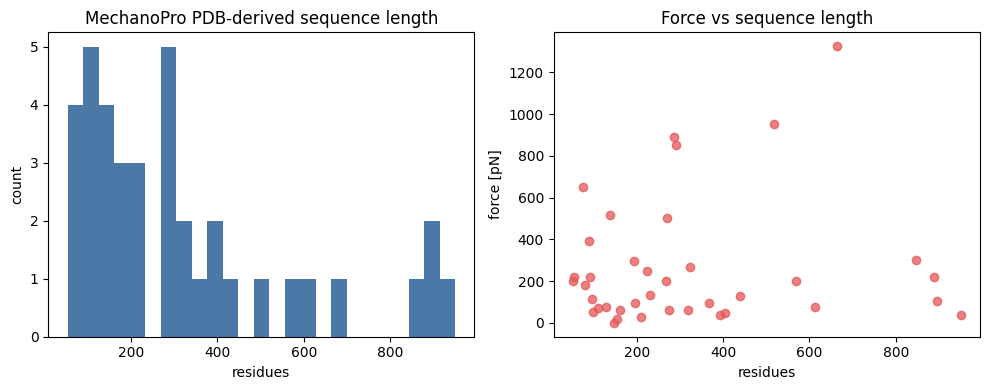

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(entries['sequence_length_from_pdb'], bins=25, color='#4C78A8')
axes[0].set_title('MechanoPro PDB-derived sequence length')
axes[0].set_xlabel('residues')
axes[0].set_ylabel('count')
axes[1].scatter(entries['sequence_length_from_pdb'], entries['experimental_force_pn'], color='#E45756', alpha=0.75)
axes[1].set_title('Force vs sequence length')
axes[1].set_xlabel('residues')
axes[1].set_ylabel('force [pN]')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'mechanopro_sequence_length_vs_force.png', dpi=200)
plt.show()


## 3. Prepare ColabFold no-MSA Input and Predict Structures

Important: per the project runtime rule, this notebook only sets `CUDA_PATH` and prepends `${CUDA_PATH}/bin` to `PATH` before launching ColabFold. It does not modify the dynamic-library search path.


In [7]:
def write_fasta(path: Path, name: str, sequence: str) -> None:
    path.write_text(f'>{name}\n{sequence}', encoding='utf-8')

COLABFOLD_INPUT_DIR.mkdir(parents=True, exist_ok=True)
for row in entries.itertuples(index=False):
    write_fasta(COLABFOLD_INPUT_DIR / f'{row.job_id}.fasta', row.job_id, row.sequence)

colab_input = entries[['pdb_id', 'job_id', 'experimental_force_pn', 'sequence_length_from_pdb', 'sequence']].copy()
colab_input['colabfold_input_fasta'] = colab_input['job_id'].map(lambda x: str(COLABFOLD_INPUT_DIR / f'{x}.fasta'))
colab_input.to_csv(TABLE_DIR / 'mechanopro_colabfold_input_sequences.csv', index=False)
print('FASTA files:', len(list(COLABFOLD_INPUT_DIR.glob('*.fasta'))))
display(colab_input.head())


FASTA files: 38


,pdb_id,job_id,experimental_force_pn,sequence_length_from_pdb,sequence,colabfold_input_fasta
0,1AJ3,1AJ3,50.000000,98,HQFFRDMDDEESWIKEKKLLVSSEDYGRDLTGVQNLRKKHKRLEAE...,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...
1,1ANU,1ANU,514.666667,138,VVVEIGKVTGSVGTTVEIPVYFRGVPSKGIANCDFVFRYDPNVLEI...,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...
2,1AOH,1AOH,850.000000,290,AVRIKVDTVNAKPGDTVRIPVRFSGIPSKGIANCDFVYSYDPNVLE...,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...
3,1AT9,1AT9,133.333333,230,AQITGRPEWIWLALGTALMGLGTLYFLVKGMGVSDPDAKKFYAITT...,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...
4,1B6I,1B6I,64.000000,162,MNIFEMLRIDEGLRLKIYKDCEGYYTIGIGHLLTKSPSLNAAKSEL...,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...


In [8]:
def build_colabfold_env() -> dict:
    env = dict(os.environ)
    env['CUDA_PATH'] = str(CUDA_HOME)
    env['PATH'] = f"{CUDA_HOME / 'bin'}:{env.get('PATH', '')}"
    # Deliberately leave the dynamic-library search path unchanged; changing it can hide GPU detection in this environment.
    env['XLA_FLAGS'] = f"--xla_gpu_cuda_data_dir={CUDA_HOME} {env.get('XLA_FLAGS', '')}".strip()
    env['MPLCONFIGDIR'] = '/tmp/mprl-matplotlib-cache'
    env['XDG_CACHE_HOME'] = '/tmp/mprl-xdg-cache'
    env['PYTHONUNBUFFERED'] = '1'
    return env

NO_GPU_RUNTIME_PATTERNS = (
    'no gpu detected',
    "unable to initialize backend 'cuda'",
    'unable to initialize backend cuda',
    'failed to initialize cuda',
    'cuda_error_no_device',
    'could not find cuda',
)

def run_colabfold_with_runtime_gpu_detection(command: list[str], env: dict) -> int:
    log_lines = []
    log_path = PREDICT_ROOT / 'colabfold_runtime.log'
    status_path = PREDICT_ROOT / 'colabfold_runtime_status.json'
    process = subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1, env=env)
    no_gpu_line = None
    timeout_reason = None
    start_time = time.monotonic()
    try:
        assert process.stdout is not None
        while True:
            ready, _, _ = select.select([process.stdout], [], [], 1.0)
            if not ready:
                if process.poll() is not None:
                    break
                if not log_lines and STARTUP_LOG_TIMEOUT_SECONDS is not None:
                    if time.monotonic() - start_time > STARTUP_LOG_TIMEOUT_SECONDS:
                        timeout_reason = f'No ColabFold runtime log appeared within {STARTUP_LOG_TIMEOUT_SECONDS} seconds.'
                        process.terminate()
                        try:
                            process.wait(timeout=20)
                        except subprocess.TimeoutExpired:
                            process.kill()
                            process.wait(timeout=20)
                        break
                continue
            line = process.stdout.readline()
            if line == '' and process.poll() is not None:
                break
            print(line, end='')
            log_lines.append(line)
            lower = line.lower()
            if REQUIRE_GPU_FOR_COLABFOLD and any(pattern in lower for pattern in NO_GPU_RUNTIME_PATTERNS):
                no_gpu_line = line.strip()
                process.terminate()
                try:
                    process.wait(timeout=20)
                except subprocess.TimeoutExpired:
                    process.kill()
                    process.wait(timeout=20)
                break
        return_code = process.wait()
    finally:
        log_path.write_text(''.join(log_lines), encoding='utf-8')
    status = {
        'return_code': int(return_code),
        'terminated_due_to_no_gpu': no_gpu_line is not None,
        'terminated_due_to_log_timeout': timeout_reason is not None,
        'no_gpu_line': no_gpu_line,
        'timeout_reason': timeout_reason,
        'command': command,
        'log_path': str(log_path),
    }
    status_path.write_text(json.dumps(status, indent=2), encoding='utf-8')
    if no_gpu_line is not None:
        raise RuntimeError(f'ColabFold reported no usable GPU during runtime; terminated. Detected line: {no_gpu_line}')
    if timeout_reason is not None:
        raise RuntimeError(f'ColabFold runtime log timeout; terminated. {timeout_reason}')
    if return_code != 0:
        raise RuntimeError(f'ColabFold prediction failed with return code {return_code}; see {log_path}.')
    return int(return_code)

colabfold_env = build_colabfold_env()
cmd = [
    str(COLABFOLD_BIN),
    '--data', str(COLABFOLD_DATA_DIR),
    '--msa-mode', 'single_sequence',
    '--model-type', 'alphafold2_ptm',
    '--num-models', '1',
    '--num-recycle', '1',
    '--amber',
    '--num-relax', '1',
    '--use-pallas', 'false',
    '--compile-mode', 'fast',
]
if OVERWRITE_EXISTING_RESULTS:
    cmd.append('--overwrite-existing-results')
cmd.extend([str(COLABFOLD_INPUT_DIR), str(COLABFOLD_RESULT_DIR)])
print('ColabFold command:')
print(' '.join(cmd))
if RUN_COLABFOLD:
    return_code = run_colabfold_with_runtime_gpu_detection(cmd, colabfold_env)
    print('ColabFold return code:', return_code)
else:
    print('RUN_COLABFOLD=False; prediction was not launched.')


ColabFold command:
/mnt/data1/home/jianquanzhao/anaconda24/envs/colabfold/bin/colabfold_batch --data /mnt/nas/jianquanzhao/gits/Mechanical-protein-RL/output/evaluate-mechanical-predictor/colabfold-local-data --msa-mode single_sequence --model-type alphafold2_ptm --num-models 1 --num-recycle 1 --amber --num-relax 1 --use-pallas false --compile-mode fast /mnt/nas/jianquanzhao/gits/Mechanical-protein-RL/output/evaluate-mechanical-predictor/pdb-colab/compared_based_predicted-MechanoPro-DB/input-fasta /mnt/nas/jianquanzhao/gits/Mechanical-protein-RL/output/evaluate-mechanical-predictor/pdb-colab/compared_based_predicted-MechanoPro-DB/results
2026-07-16 17:18:42,361 Running colabfold 1.6.2
2026-07-16 17:18:43,742 Running on GPU
2026-07-16 17:18:43,938 Found 3 citations for tools or databases
2026-07-16 17:18:43,939 Query 1/38: 1BRF (length 53)
2026-07-16 17:18:52,214 Padding length to 63
E0716 17:19:03.168471 3188549 cuda_timer.cc:88] Delay kernel timed out: measured time has sub-optimal acc

## 4. Evaluate Predicted and Ground-Truth Structures

The same terminal reward calculator is used for both structure sources. The experimental target is the aggregated MechanoPro force, so the analysis reports correlations between force and both predicted heads.


In [9]:
from model.reward_module.terminal_reward import HbondTopologyTerminalRewardCalculator, TerminalRewardScalarization

calculator = HbondTopologyTerminalRewardCalculator(
    artifact_path=MODEL_ARTIFACT_PATH,
    scalarization=TerminalRewardScalarization(strength_weight=1.0, toughness_weight=1.0),
)
artifact = calculator.artifact
print('artifact features:', artifact.selected_features)
print('artifact train/val/test:', artifact.train_size, artifact.val_size, artifact.test_size)


/mnt/data1/home/jianquanzhao/anaconda24/envs/mprl-vgpt/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/mnt/data1/home/jianquanzhao/anaconda24/envs/mprl-vgpt/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


artifact features: ('sequence_length', 'hbond_per_residue', 'seq_class_nonlocal_per_residue', 'strong_nonlocal_fraction', 'strong_nonlocal_per_residue', 'nonlocal_backbone_backbone_per_residue', 'hbond_contact_order')
artifact train/val/test: 5632 704 705


/mnt/data1/home/jianquanzhao/anaconda24/envs/mprl-vgpt/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MultiOutputRegressor from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [10]:
def best_predicted_pdb(job_id: str) -> Optional[Path]:
    patterns = [
        f'{job_id}_relaxed_rank_001*.pdb',
        f'{job_id}*relaxed_rank_001*.pdb',
        f'{job_id}_unrelaxed_rank_001*.pdb',
        f'{job_id}*rank_001*.pdb',
        f'{job_id}*.pdb',
    ]
    candidates = []
    for pattern in patterns:
        candidates.extend(COLABFOLD_RESULT_DIR.glob(pattern))
    candidates = sorted(set(candidates))
    return candidates[0] if candidates else None


def evaluate_structure_rows(frame: pd.DataFrame, path_column: str, source_label: str) -> pd.DataFrame:
    rows = []
    for row in frame.itertuples(index=False):
        pdb_path = getattr(row, path_column)
        base = {
            'pdb_id': row.pdb_id,
            'source': source_label,
            'experimental_force_pn': float(row.experimental_force_pn),
            'force_std_pn': float(row.force_std_pn),
            'n_measurements': int(row.n_measurements),
            'sequence_length_from_pdb': int(row.sequence_length_from_pdb),
            'pdb_path': pdb_path,
        }
        if not pdb_path or not Path(pdb_path).exists():
            rows.append({**base, 'ok': False, 'error': 'missing pdb'})
            continue
        try:
            result = calculator.evaluate_pdb(pdb_path)
            record = {
                **base,
                'ok': True,
                'predicted_toughness_v127': result.toughness,
                'predicted_strength_v128': result.strength,
                'terminal_reward': result.reward,
                'mean_plddt': result.feature_diagnostics.get('mean_plddt'),
                'hbond_count': result.feature_diagnostics.get('hbond_count'),
                'hydrogen_atom_count': result.feature_diagnostics.get('hydrogen_atom_count'),
                'feature_warnings': ';'.join(result.feature_diagnostics.get('warnings', ())),
            }
            for key, value in result.features.items():
                record[f'feature_{key}'] = value
            rows.append(record)
        except Exception as exc:
            rows.append({**base, 'ok': False, 'error': repr(exc)})
    return pd.DataFrame(rows)

entries['predicted_pdb_path'] = entries['job_id'].map(lambda x: str(best_predicted_pdb(x) or ''))

groundtruth_eval = evaluate_structure_rows(entries, 'groundtruth_pdb_path', 'groundtruth_rcsb_structure')
predicted_eval = evaluate_structure_rows(entries, 'predicted_pdb_path', 'colabfold_predicted_structure')

groundtruth_eval.to_csv(TABLE_DIR / 'mechanopro_groundtruth_structure_predictions.csv', index=False)
predicted_eval.to_csv(TABLE_DIR / 'mechanopro_colabfold_predicted_structure_predictions.csv', index=False)
print('groundtruth ok:', int(groundtruth_eval['ok'].fillna(False).sum()), '/', len(groundtruth_eval))
print('predicted ok:', int(predicted_eval['ok'].fillna(False).sum()), '/', len(predicted_eval))
display(groundtruth_eval.head())
display(predicted_eval.head())


groundtruth ok: 38 / 38
predicted ok: 38 / 38


,pdb_id,source,experimental_force_pn,force_std_pn,n_measurements,sequence_length_from_pdb,pdb_path,ok,predicted_toughness_v127,predicted_strength_v128,...,hbond_count,hydrogen_atom_count,feature_warnings,feature_sequence_length,feature_hbond_per_residue,feature_seq_class_nonlocal_per_residue,feature_strong_nonlocal_fraction,feature_strong_nonlocal_per_residue,feature_nonlocal_backbone_backbone_per_residue,feature_hbond_contact_order
0,1AJ3,groundtruth_rcsb_structure,50.000000,28.284271,2,98,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...,True,427.555918,650.570594,...,258617,15860,,98.0,2638.94898,61.234694,0.002861,7.55102,6.94898,0.030097
1,1ANU,groundtruth_rcsb_structure,514.666667,325.308059,3,138,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...,True,357.190781,840.749191,...,0,0,No hydrogen atoms were found; hbond features w...,138.0,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000
2,1AOH,groundtruth_rcsb_structure,850.000000,456.398948,3,290,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...,True,357.221169,907.312799,...,0,0,No hydrogen atoms were found; hbond features w...,290.0,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000
3,1AT9,groundtruth_rcsb_structure,133.333333,28.867513,3,230,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...,True,357.421160,903.202755,...,0,0,No hydrogen atoms were found; hbond features w...,230.0,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000
4,1B6I,groundtruth_rcsb_structure,64.000000,0.000000,1,162,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...,True,353.218196,910.098342,...,0,0,No hydrogen atoms were found; hbond features w...,162.0,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000


,pdb_id,source,experimental_force_pn,force_std_pn,n_measurements,sequence_length_from_pdb,pdb_path,ok,predicted_toughness_v127,predicted_strength_v128,...,hbond_count,hydrogen_atom_count,feature_warnings,feature_sequence_length,feature_hbond_per_residue,feature_seq_class_nonlocal_per_residue,feature_strong_nonlocal_fraction,feature_strong_nonlocal_per_residue,feature_nonlocal_backbone_backbone_per_residue,feature_hbond_contact_order
0,1AJ3,colabfold_predicted_structure,50.000000,28.284271,2,98,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...,True,323.995211,706.391156,...,77,795,,98.0,0.785714,0.010204,0.000000,0.000000,0.000000,0.040154
1,1ANU,colabfold_predicted_structure,514.666667,325.308059,3,138,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...,True,306.191095,660.973786,...,42,1037,,138.0,0.304348,0.152174,0.142857,0.043478,0.115942,0.216184
2,1AOH,colabfold_predicted_structure,850.000000,456.398948,3,290,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...,True,319.762280,751.560158,...,97,2176,,290.0,0.334483,0.148276,0.195876,0.065517,0.120690,0.037895
3,1AT9,colabfold_predicted_structure,133.333333,28.867513,3,230,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...,True,355.972946,824.343717,...,187,1842,,230.0,0.813043,0.000000,0.000000,0.000000,0.000000,0.016461
4,1B6I,colabfold_predicted_structure,64.000000,0.000000,1,162,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...,True,341.959085,765.924006,...,140,1309,,162.0,0.864198,0.111111,0.057143,0.049383,0.074074,0.028527


## 5. Metrics, Figures, and Interpretation


In [11]:
def safe_corr(x, y):
    frame = pd.DataFrame({'x': x, 'y': y}).replace([np.inf, -np.inf], np.nan).dropna()
    if len(frame) < 3 or frame['x'].nunique() < 2 or frame['y'].nunique() < 2:
        return {'n': int(len(frame)), 'pearson': np.nan, 'pearson_p': np.nan, 'spearman': np.nan, 'spearman_p': np.nan}
    pear = pearsonr(frame['x'], frame['y'])
    spear = spearmanr(frame['x'], frame['y'])
    return {'n': int(len(frame)), 'pearson': float(pear.statistic), 'pearson_p': float(pear.pvalue), 'spearman': float(spear.statistic), 'spearman_p': float(spear.pvalue)}


def metric_rows(frame: pd.DataFrame, source_label: str) -> list[dict]:
    if 'ok' in frame.columns:
        frame = frame[frame['ok'].fillna(False)].copy()
    rows = []
    for pred_col, head_label in [
        ('predicted_toughness_v127', 'toughness_head_v127'),
        ('predicted_strength_v128', 'strength_head_v128'),
        ('terminal_reward', 'terminal_reward'),
    ]:
        if pred_col not in frame.columns:
            continue
        stats = safe_corr(frame['experimental_force_pn'], frame[pred_col])
        rows.append({'source': source_label, 'predictor': head_label, **stats})
    return rows

metrics = []
metrics.extend(metric_rows(groundtruth_eval, 'groundtruth_rcsb_structure'))
metrics.extend(metric_rows(predicted_eval, 'colabfold_predicted_structure'))
metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv(TABLE_DIR / 'mechanopro_force_correlation_metrics.csv', index=False)
display(metrics_df)

paired = predicted_eval[predicted_eval.get('ok', False).fillna(False)].merge(
    groundtruth_eval[groundtruth_eval.get('ok', False).fillna(False)][['pdb_id', 'predicted_toughness_v127', 'predicted_strength_v128', 'terminal_reward']],
    on='pdb_id',
    how='inner',
    suffixes=('_predicted_structure', '_groundtruth_structure'),
)
paired.to_csv(TABLE_DIR / 'mechanopro_predicted_vs_groundtruth_paired.csv', index=False)
print('paired predicted/groundtruth rows:', len(paired))


,source,predictor,n,pearson,pearson_p,spearman,spearman_p
0,groundtruth_rcsb_structure,toughness_head_v127,38,-0.215572,0.193659,-0.271710,0.098903
1,groundtruth_rcsb_structure,strength_head_v128,38,0.064232,0.701628,-0.030245,0.856952
2,groundtruth_rcsb_structure,terminal_reward,38,-0.074629,0.656105,-0.203362,0.220735
3,colabfold_predicted_structure,toughness_head_v127,38,-0.185966,0.263627,-0.374254,0.020622
4,colabfold_predicted_structure,strength_head_v128,38,-0.171338,0.303694,-0.391549,0.015058
5,colabfold_predicted_structure,terminal_reward,38,-0.197636,0.234287,-0.387390,0.016264


paired predicted/groundtruth rows: 38


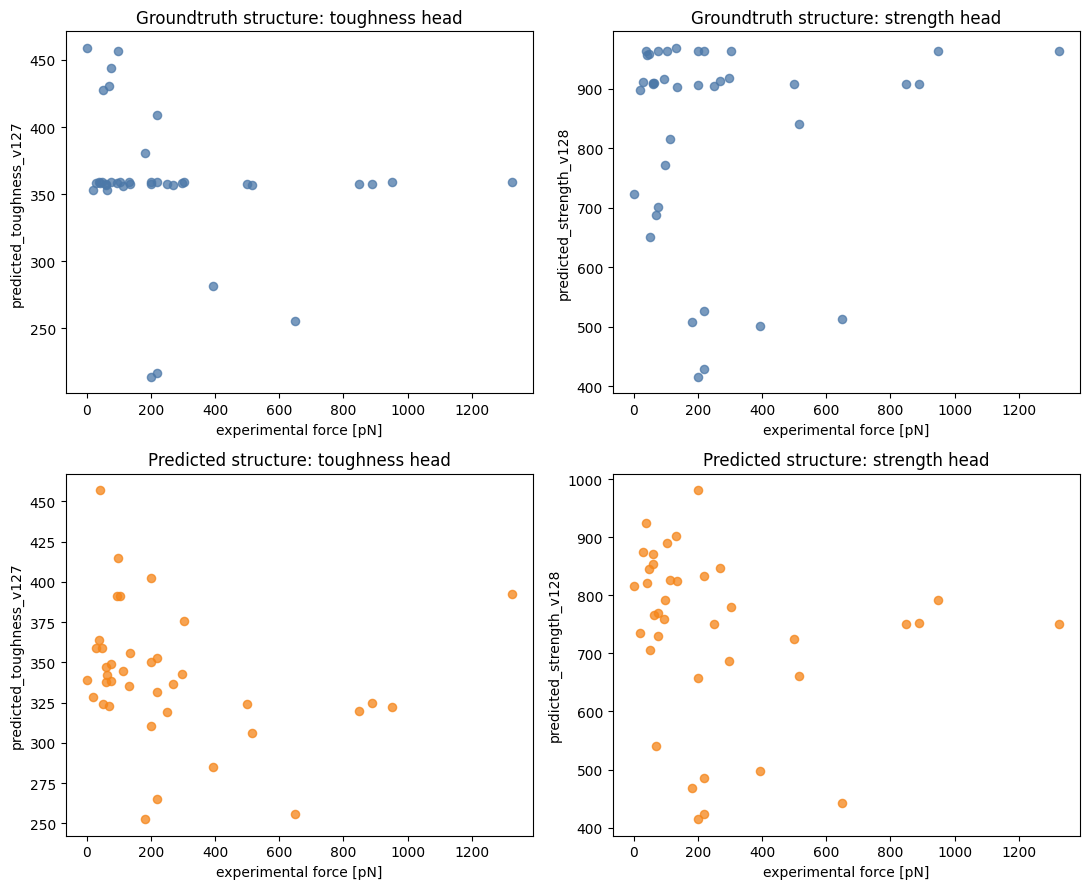

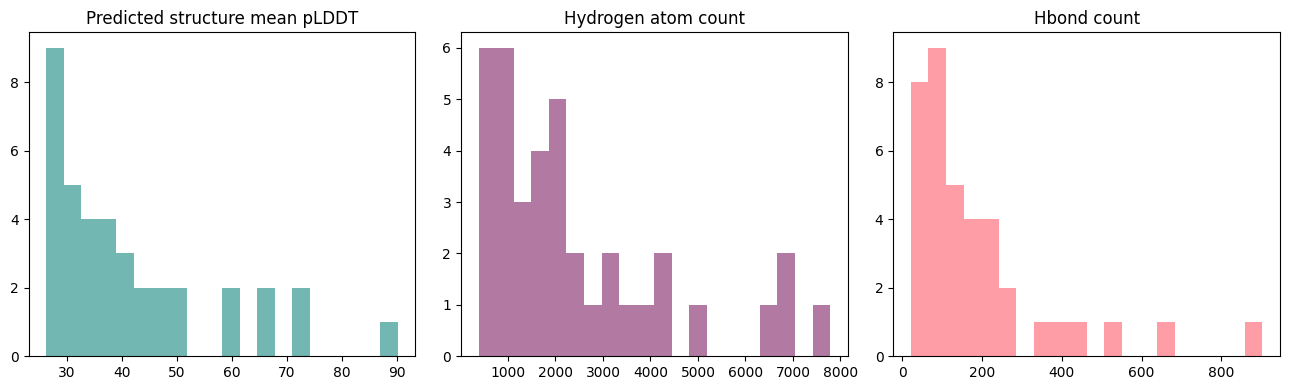

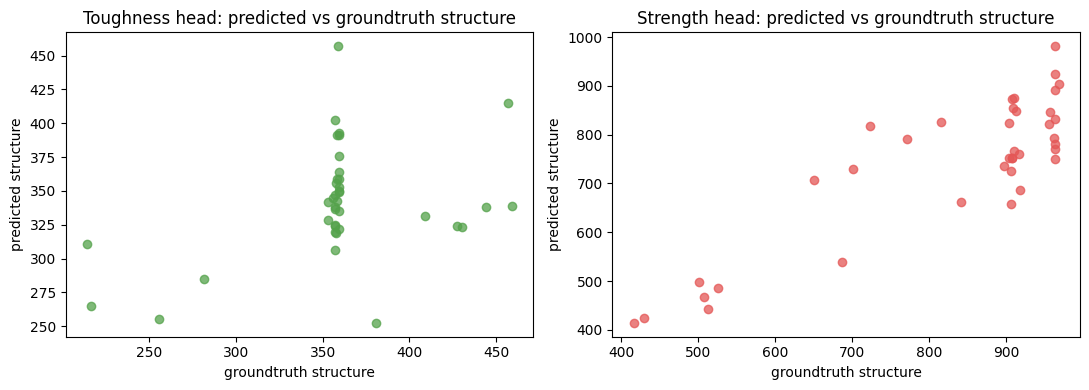

In [12]:
def scatter_force(ax, frame, pred_col, title, color):
    sub = frame[frame.get('ok', True).fillna(False)] if 'ok' in frame.columns else frame
    sub = sub[['experimental_force_pn', pred_col]].replace([np.inf, -np.inf], np.nan).dropna()
    ax.scatter(sub['experimental_force_pn'], sub[pred_col], s=35, alpha=0.75, color=color)
    ax.set_xlabel('experimental force [pN]')
    ax.set_ylabel(pred_col)
    ax.set_title(title)

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
scatter_force(axes[0, 0], groundtruth_eval, 'predicted_toughness_v127', 'Groundtruth structure: toughness head', '#4C78A8')
scatter_force(axes[0, 1], groundtruth_eval, 'predicted_strength_v128', 'Groundtruth structure: strength head', '#4C78A8')
scatter_force(axes[1, 0], predicted_eval, 'predicted_toughness_v127', 'Predicted structure: toughness head', '#F58518')
scatter_force(axes[1, 1], predicted_eval, 'predicted_strength_v128', 'Predicted structure: strength head', '#F58518')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'mechanopro_force_vs_predictions_scatter.png', dpi=200)
plt.show()

valid_pred = predicted_eval[predicted_eval.get('ok', False).fillna(False)].copy() if len(predicted_eval) else predicted_eval
if len(valid_pred):
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    axes[0].hist(valid_pred['mean_plddt'].dropna(), bins=20, color='#72B7B2')
    axes[0].set_title('Predicted structure mean pLDDT')
    axes[1].hist(valid_pred['hydrogen_atom_count'].dropna(), bins=20, color='#B279A2')
    axes[1].set_title('Hydrogen atom count')
    axes[2].hist(valid_pred['hbond_count'].dropna(), bins=20, color='#FF9DA6')
    axes[2].set_title('Hbond count')
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / 'mechanopro_predicted_structure_quality_features.png', dpi=200)
    plt.show()

if len(paired):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].scatter(paired['predicted_toughness_v127_groundtruth_structure'], paired['predicted_toughness_v127_predicted_structure'], color='#54A24B', alpha=0.75)
    axes[0].set_title('Toughness head: predicted vs groundtruth structure')
    axes[0].set_xlabel('groundtruth structure')
    axes[0].set_ylabel('predicted structure')
    axes[1].scatter(paired['predicted_strength_v128_groundtruth_structure'], paired['predicted_strength_v128_predicted_structure'], color='#E45756', alpha=0.75)
    axes[1].set_title('Strength head: predicted vs groundtruth structure')
    axes[1].set_xlabel('groundtruth structure')
    axes[1].set_ylabel('predicted structure')
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / 'mechanopro_predicted_vs_groundtruth_heads.png', dpi=200)
    plt.show()


In [13]:
analysis_summary = {
    'raw_rows': int(len(raw)),
    'clean_measurement_rows': int(len(clean)),
    'unique_pdb_entries': int(len(agg)),
    'entries_with_sequence': int(len(entries)),
    'groundtruth_eval_ok': int(groundtruth_eval['ok'].fillna(False).sum()) if len(groundtruth_eval) else 0,
    'predicted_eval_ok': int(predicted_eval['ok'].fillna(False).sum()) if len(predicted_eval) else 0,
    'metrics': metrics_df.to_dict(orient='records'),
    'notes': [
        'Experimental force is not the same target as simulated v127/v128, so correlations are external association tests.',
        'Duplicate PDB IDs are averaged by PDB ID; measurement dispersion is retained.',
        'Both toughness and strength heads should be compared with the single experimental force label.',
    ],
}
(OUT_DIR / 'mechanopro_comparison_summary.json').write_text(json.dumps(analysis_summary, indent=2), encoding='utf-8')
print(json.dumps(analysis_summary, indent=2))


{
  "raw_rows": 85,
  "clean_measurement_rows": 85,
  "unique_pdb_entries": 38,
  "entries_with_sequence": 38,
  "groundtruth_eval_ok": 38,
  "predicted_eval_ok": 38,
  "metrics": [
    {
      "source": "groundtruth_rcsb_structure",
      "predictor": "toughness_head_v127",
      "n": 38,
      "pearson": -0.21557206113853644,
      "pearson_p": 0.19365943100253483,
      "spearman": -0.27171041360259923,
      "spearman_p": 0.09890309294507546
    },
    {
      "source": "groundtruth_rcsb_structure",
      "predictor": "strength_head_v128",
      "n": 38,
      "pearson": 0.0642323894496068,
      "pearson_p": 0.7016276932572383,
      "spearman": -0.030244925759163568,
      "spearman_p": 0.856952220164151
    },
    {
      "source": "groundtruth_rcsb_structure",
      "predictor": "terminal_reward",
      "n": 38,
      "pearson": -0.07462873445899562,
      "pearson_p": 0.656105478182513,
      "spearman": -0.20336198902522015,
      "spearman_p": 0.2207349813751395
    },
    {

## 6. Failure Analysis and Top-k Hit Analysis

The weak external correlation on MechanoPro-DB is not only a model-capacity issue. It is mainly a target/domain mismatch issue:

1. The random-forest reward model was trained on simulated `v127` and `v128`; MechanoPro-DB reports experimental unfolding/clamp force in pN. These are related mechanical observables, but they are not identical labels.
2. The experimental force is loading-path dependent. Pulling geometry, clamp residues, construct boundary, mutation state, oligomeric state, and measurement protocol can change force for the same or similar fold, while the current predictor only uses static topology and hydrogen-bond-network descriptors.
3. Duplicate PDB IDs in MechanoPro-DB can reflect different experimental modes. Averaging duplicate forces gives a clean first benchmark, but it can blur physically meaningful measurement heterogeneity.
4. Groundtruth RCSB structures and ColabFold structures are static equilibrium structures. They do not explicitly encode unfolding pathways, transition states, or force-propagation routes.
5. RCSB files can differ in chain selection, biological assembly, missing atoms, hydrogen treatment, and protonation. These details strongly affect hydrogen-bond features.
6. The benchmark has only 38 aggregated PDB entries, so a few high-force outliers can dominate Pearson/Spearman trends.

Because the downstream use case is screening, the following section adds a top-k hit-rate analysis. A hit means that an entry ranked in the model top-k is also in the experimental-force top-k.

In [ ]:
from pathlib import Path
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base_dir = Path('output/evaluate-mechanical-predictor/compared_based_predicted-MechanoPro-DB')
table_dir = base_dir / 'tables'
figure_dir = base_dir / 'figures'
table_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

source_files = [
    ('groundtruth_rcsb_structure', table_dir / 'mechanopro_groundtruth_structure_predictions.csv'),
    ('colabfold_predicted_structure', table_dir / 'mechanopro_colabfold_predicted_structure_predictions.csv'),
]
score_specs = [
    ('toughness_head_v127', 'predicted_toughness_v127', 'higher'),
    ('strength_head_v128', 'predicted_strength_v128', 'higher'),
    ('terminal_reward', 'terminal_reward', 'higher'),
    # Diagnostic controls: useful when the global correlation is negative.
    ('inverse_toughness_head_v127_diagnostic', 'predicted_toughness_v127', 'lower'),
    ('inverse_strength_head_v128_diagnostic', 'predicted_strength_v128', 'lower'),
]
ks_absolute = [3, 5, 10]
top_fractions = [0.10, 0.20, 0.30]

rows = []
leaderboard_rows = []
for source_name, csv_path in source_files:
    frame = pd.read_csv(csv_path)
    if 'ok' in frame.columns:
        frame = frame[frame['ok'].fillna(False).astype(bool)].copy()
    frame = frame.dropna(subset=['pdb_id', 'experimental_force_pn']).copy()
    n = len(frame)
    if n == 0:
        continue

    true_order = frame.sort_values('experimental_force_pn', ascending=False)
    k_specs = [('k_abs', k, min(k, n)) for k in ks_absolute]
    for frac in top_fractions:
        k_specs.append(('top_fraction', frac, min(max(1, int(math.ceil(frac * n))), n)))

    for predictor_name, score_col, direction in score_specs:
        if score_col not in frame.columns:
            continue
        score_frame = frame.dropna(subset=[score_col]).copy()
        if score_frame.empty:
            continue
        pred_order = score_frame.sort_values(score_col, ascending=(direction == 'lower'))

        for k_type, k_label, k in k_specs:
            k = min(k, len(score_frame), n)
            true_top = true_order.head(k)
            pred_top = pred_order.head(k)
            true_ids = set(true_top['pdb_id'].astype(str))
            pred_ids = set(pred_top['pdb_id'].astype(str))
            hit_ids = sorted(true_ids & pred_ids)
            hit_count = len(hit_ids)
            hit_rate = hit_count / k
            baseline_rate = k / n
            mean_force_pred_topk = float(pred_top['experimental_force_pn'].mean())
            mean_force_true_topk = float(true_top['experimental_force_pn'].mean())
            mean_force_all = float(score_frame['experimental_force_pn'].mean())

            rows.append({
                'source': source_name,
                'predictor': predictor_name,
                'ranking_direction': direction,
                'k_type': k_type,
                'k_label': k_label,
                'n': n,
                'k': k,
                'hit_count': hit_count,
                'hit_rate': hit_rate,
                'baseline_rate': baseline_rate,
                'enrichment_factor': hit_rate / baseline_rate if baseline_rate else np.nan,
                'mean_true_force_in_pred_topk': mean_force_pred_topk,
                'mean_true_force_in_true_topk': mean_force_true_topk,
                'mean_true_force_overall': mean_force_all,
                'topk_force_lift_vs_overall': mean_force_pred_topk / mean_force_all if mean_force_all else np.nan,
                'topk_force_lift_vs_true_topk': mean_force_pred_topk / mean_force_true_topk if mean_force_true_topk else np.nan,
                'true_top_pdb_ids': ','.join(true_top['pdb_id'].astype(str).tolist()),
                'pred_top_pdb_ids': ','.join(pred_top['pdb_id'].astype(str).tolist()),
                'hit_pdb_ids': ','.join(hit_ids),
            })

        leader = pred_order.head(10)[['pdb_id', 'experimental_force_pn', score_col]].copy()
        leader.columns = ['pdb_id', 'experimental_force_pn', 'score']
        leader.insert(0, 'source', source_name)
        leader.insert(1, 'predictor', predictor_name)
        leader.insert(2, 'ranking_direction', direction)
        leader.insert(3, 'rank_by_score', range(1, len(leader) + 1))
        leaderboard_rows.extend(leader.to_dict('records'))

topk = pd.DataFrame(rows)
leaderboard = pd.DataFrame(leaderboard_rows)
topk_path = table_dir / 'mechanopro_topk_hit_analysis.csv'
leaderboard_path = table_dir / 'mechanopro_top10_leaderboard_by_score.csv'
topk.to_csv(topk_path, index=False)
leaderboard.to_csv(leaderboard_path, index=False)

primary = topk[~topk['predictor'].str.contains('inverse_', regex=False)].copy()
plot_k = primary[(primary['k_type'] == 'k_abs') & (primary['k'] == 5)].copy()
if not plot_k.empty:
    plot_k['label'] = (
        plot_k['source'].str.replace('_structure', '', regex=False).str.replace('_', ' ', regex=False)
        + '\n'
        + plot_k['predictor'].str.replace('_head_', '\n', regex=False)
    )
    fig, ax = plt.subplots(figsize=(11, 5))
    colors = ['#4C78A8' if 'groundtruth' in source else '#F58518' for source in plot_k['source']]
    ax.bar(range(len(plot_k)), plot_k['hit_rate'], color=colors)
    ax.axhline(plot_k['baseline_rate'].iloc[0], color='black', linestyle='--', linewidth=1, label='random baseline')
    ax.set_xticks(range(len(plot_k)))
    ax.set_xticklabels(plot_k['label'], rotation=35, ha='right')
    ax.set_ylabel('Top-5 hit rate')
    ax.set_title('MechanoPro-DB top-5 hit rate for high experimental force')
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(figure_dir / 'mechanopro_topk_hit_rate.png', dpi=200)
    plt.show()

plot_frac = primary[primary['k_type'] == 'top_fraction'].copy()
if not plot_frac.empty:
    plot_frac['fraction_label'] = (plot_frac['k_label'].astype(float) * 100).round().astype(int).astype(str) + '%'
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
    for ax, source_name in zip(axes, ['groundtruth_rcsb_structure', 'colabfold_predicted_structure']):
        sub = plot_frac[plot_frac['source'] == source_name]
        for predictor_name in ['toughness_head_v127', 'strength_head_v128', 'terminal_reward']:
            ss = sub[sub['predictor'] == predictor_name].sort_values('k_label')
            if not ss.empty:
                ax.plot(ss['fraction_label'], ss['enrichment_factor'], marker='o', label=predictor_name)
        ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
        ax.set_title(source_name.replace('_', ' '))
        ax.set_xlabel('Top fraction')
        ax.set_ylabel('Enrichment factor')
        ax.legend(frameon=False, fontsize=8)
    fig.suptitle('MechanoPro-DB top-fraction enrichment for high experimental force', y=1.03)
    fig.tight_layout()
    fig.savefig(figure_dir / 'mechanopro_topk_enrichment.png', dpi=200, bbox_inches='tight')
    plt.show()

summary_rows = []
for source_name in ['groundtruth_rcsb_structure', 'colabfold_predicted_structure']:
    for predictor_name in ['toughness_head_v127', 'strength_head_v128', 'terminal_reward', 'inverse_toughness_head_v127_diagnostic']:
        ss = topk[(topk['source'] == source_name) & (topk['predictor'] == predictor_name) & (topk['k_type'] == 'k_abs') & (topk['k'] == 5)]
        if not ss.empty:
            row = ss.iloc[0]
            summary_rows.append({
                'source': source_name,
                'predictor': predictor_name,
                'k': int(row['k']),
                'hit_count': int(row['hit_count']),
                'hit_rate': float(row['hit_rate']),
                'baseline_rate': float(row['baseline_rate']),
                'enrichment_factor': float(row['enrichment_factor']),
                'mean_true_force_in_pred_topk': float(row['mean_true_force_in_pred_topk']),
                'hit_pdb_ids': row['hit_pdb_ids'],
                'pred_top_pdb_ids': row['pred_top_pdb_ids'],
            })

summary = {
    'n_entries': int(topk['n'].max()) if not topk.empty else 0,
    'definition': 'True positives are overlaps between model top-k by score and experimental-force top-k by pN.',
    'top5_summary': summary_rows,
    'tables': {
        'topk_hit_analysis': str(topk_path),
        'top10_leaderboard_by_score': str(leaderboard_path),
    },
    'figures': [
        str(figure_dir / 'mechanopro_topk_hit_rate.png'),
        str(figure_dir / 'mechanopro_topk_enrichment.png'),
    ],
}
with open(table_dir / 'mechanopro_topk_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

pd.DataFrame(summary_rows)

### Top-k Interpretation

For this external MechanoPro-DB benchmark, top-k hit rate should be read as screening performance rather than regression accuracy. If the model were useful for selecting high-force proteins, its top-ranked entries should be enriched for entries with high experimental unfolding/clamp force. Low hit rate or enrichment below 1 indicates that the model is not selecting the experimental high-force tail better than chance.

The diagnostic inverse-ranking rows are not a proposed reward. They are included to verify whether the observed negative correlation has practical ranking consequences. If inverse ranking performs better than normal ranking, it supports the interpretation that the present simulated-label reward is misaligned with this experimental force endpoint.